# Exercise 7.6 — Q1: House Purchase Decision Tree

**Lab Book §7.6 Exercise 1 (page 30):**  
> In a classification tree, the data set splits according to its variables.
> In this scenario, you have two variables, **age** and **income**,
> determining whether someone buys a house. If training data tells us that
> 70 percent of people over age 30 bought a house, then the data gets split
> there, with age becoming the first node in the tree. This split makes
> the data 80 percent "pure." The second node then addresses income from
> there.

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** Decision Tree — synthetic age+income → buys_house  
**Dataset:** `datasets/house_purchase.csv` (400 rows, 3 columns)

---

## 🎯 Objective

Build a Decision Tree on `age` and `income` to predict whether someone
buys a house, exactly as described in Lab Book §7.6 Exercise 1.

## 📁 Files in this Folder

| File | Description |
|------|-------------|
| `03_Q1_House_Purchase.ipynb` | This notebook |
| `datasets/house_purchase.csv` | synthetic 400-row house-purchase dataset |


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '03-Decision-Tree-Classifier'))
    print(f'Running in Google Colab. CWD: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
_PREFIX = 'Q1_House_Purchase_'

# Patch plt.show so every figure is also auto-saved as PNG (with prefix to
# avoid collisions between multiple notebooks sharing the same outputs/ dir)
import matplotlib.pyplot as plt
_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'{_PREFIX}figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('Setup complete. Figures will be auto-saved to:', OUTPUT_DIR)


Running locally. CWD: /home/z/my-project/work/build/ML-Lab-Activities/03-Decision-Tree-Classifier


Setup complete. Figures will be auto-saved to: /home/z/my-project/work/build/ML-Lab-Activities/03-Decision-Tree-Classifier/outputs


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             classification_report)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Libraries imported.')

Libraries imported.


## 2. Load Dataset

In [3]:
df = pd.read_csv('datasets/house_purchase.csv')
print(f"Shape: {df.shape}")
display(df.head(10))
print("\nClass distribution (0 = did not buy, 1 = bought):")
print(df['buys_house'].value_counts())

Shape: (400, 3)


,age,income,buys_house
0,24,199645,0
1,54,159932,0
2,49,77675,0
3,39,194928,1
4,39,109875,0
5,58,110133,0
6,23,98065,0
7,51,45901,0
8,29,188187,0
9,24,22508,1



Class distribution (0 = did not buy, 1 = bought):
buys_house
1    253
0    147
Name: count, dtype: int64


## 3. Define Features & Target

In [4]:
X = df[['age', 'income']]
y = df['buys_house']
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (400, 2), y shape: (400,)


## 4. Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (280, 2), Test: (120, 2)


## 5. Train Decision Tree (entropy)

In [6]:
model = DecisionTreeClassifier(criterion='entropy', max_depth=3,
                                random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7917

Confusion Matrix:
[[24 20]
 [ 5 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.55      0.66        44
           1       0.78      0.93      0.85        76

    accuracy                           0.79       120
   macro avg       0.80      0.74      0.75       120
weighted avg       0.80      0.79      0.78       120



## 6. Visualise the Tree

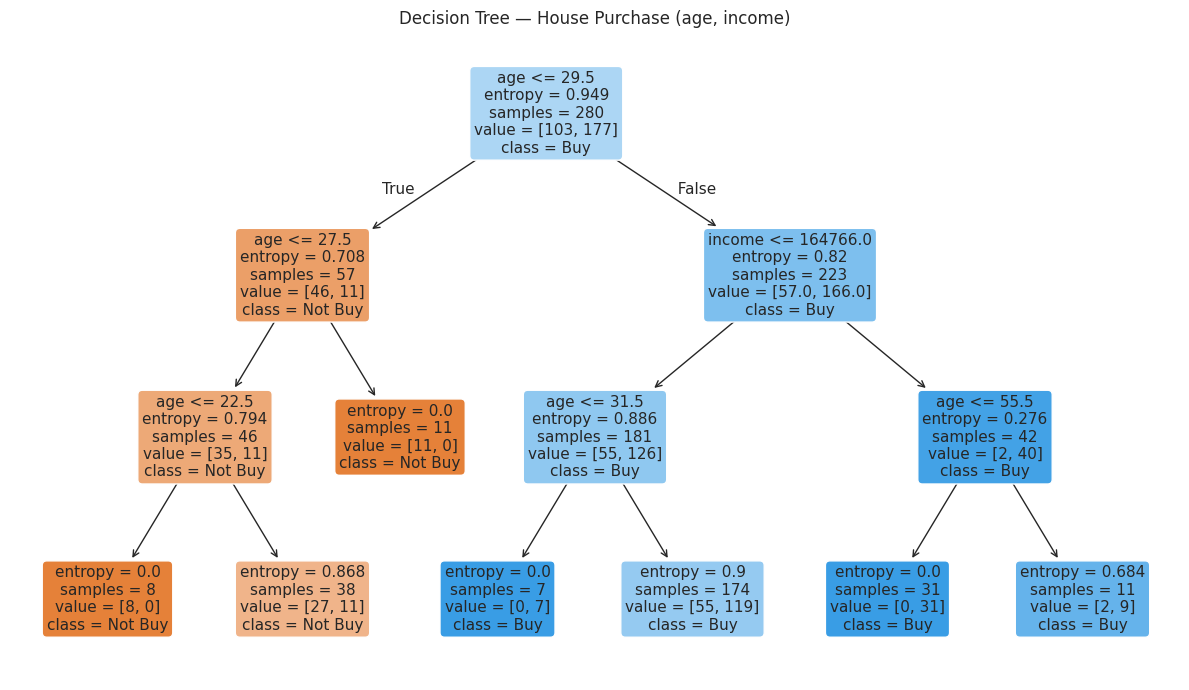

In [7]:
plt.figure(figsize=(12, 7))
plot_tree(model, feature_names=['age', 'income'],
          class_names=['Not Buy', 'Buy'],
          filled=True, rounded=True, fontsize=11)
plt.title('Decision Tree — House Purchase (age, income)')
plt.tight_layout()
plt.show()

## 7. Decision Boundary

/home/z/.venv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


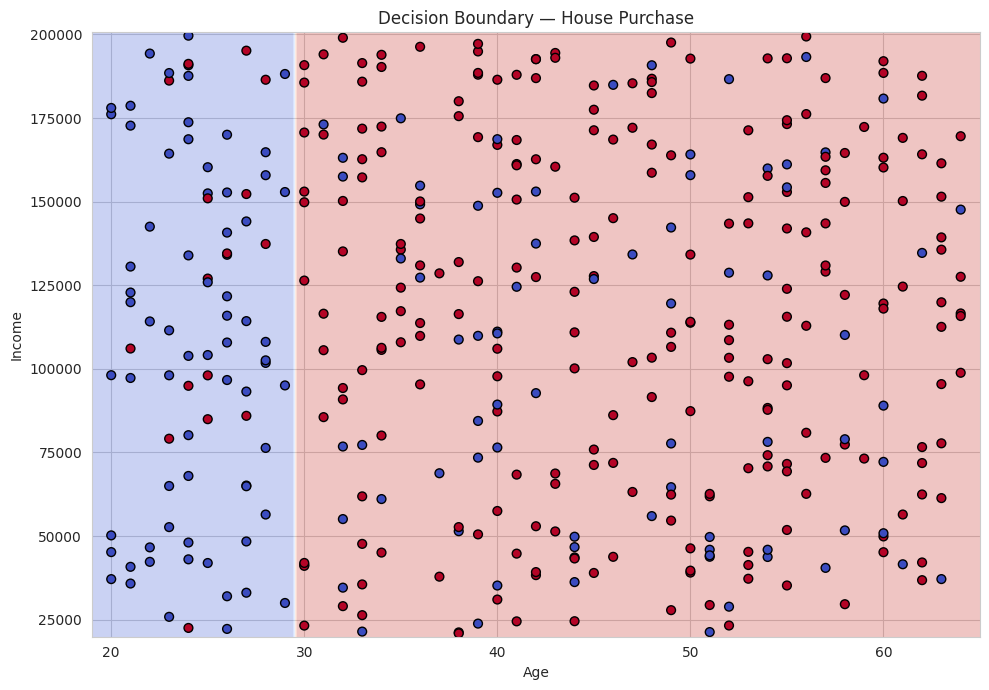

In [8]:
x_min, x_max = df['age'].min()-1, df['age'].max()+1
y_min, y_max = df['income'].min()-1000, df['income'].max()+1000
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                    np.linspace(y_min, y_max, 200))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(df['age'], df['income'], c=df['buys_house'],
            cmap='coolwarm', edgecolors='k', s=40)
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Decision Boundary — House Purchase')
plt.tight_layout()
plt.show()

## 📚 Key Takeaways
- The first split is on `age` (around 30) — exactly as the Lab Book
  describes.
- The second split is on `income` — refining the prediction.
- Decision trees produce **axis-aligned** decision boundaries (a known
  limitation when classes are linearly separable in a non-axis-aligned way).
